In [2]:
# SECTION 1  Imports & Session‑State
import sqlite3, re, uuid
from typing import List
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, END
# ──────────────────────────────────────────────────────────────
class SessionState(TypedDict):
    query: str
    sessionID: int
    currentGoalID: int | None
    currentStrategyID: int | None
    currentFunctionID: int | None
    goalSatisfied: bool

In [20]:
# SECTION 2  Drop-and-Recreate Tables  (destructive)

def init_db(drop_and_recreate: bool = True):
    """
    If drop_and_recreate == True:
        * DROP TABLE … for every managed table
        * Re-CREATE the full schema from scratch
    Otherwise:
        * Only CREATE TABLE IF NOT EXISTS (non-destructive)
    """
    conn = sqlite3.connect("agentic.db")
    cur  = conn.cursor()

    tables = [
        "FunctionParametersInstance", "FunctionOutputInstance", "FunctionInstance",
        "StrategyInstance", "StrategyLibrary",
        "FunctionParametersLibrary", "FunctionOutputLibrary", "FunctionTemplateLibrary",
        "GoalInstance"
    ]

    if drop_and_recreate:
        cur.execute("PRAGMA foreign_keys = OFF")   # disable FK checks temporarily
        for t in tables:
            cur.execute(f"DROP TABLE IF EXISTS {t}")
        cur.execute("PRAGMA foreign_keys = ON")

    # ── now re-create the schema in correct FK order ──────────
    cur.executescript("""
    CREATE TABLE IF NOT EXISTS GoalInstance(
        GoalID          INTEGER PRIMARY KEY AUTOINCREMENT,
        SessionID       INTEGER,
        GoalName        TEXT,
        GoalTarget      TEXT,
        GoalValidation  TEXT,
        GoalDescription TEXT,
        GoalSuccess     BOOLEAN
    );

    CREATE TABLE IF NOT EXISTS FunctionTemplateLibrary(
        FunctionTemplateID INTEGER PRIMARY KEY AUTOINCREMENT,
        FunctionName        TEXT,
        StrategyType        TEXT,
        FunctionDescription TEXT
    );

    CREATE TABLE IF NOT EXISTS FunctionOutputLibrary(
        FunctionOutputID INTEGER PRIMARY KEY AUTOINCREMENT,
        FunctionTemplateID INTEGER,
        OutputName TEXT, OutputValue TEXT, Type TEXT,
        FOREIGN KEY(FunctionTemplateID) REFERENCES FunctionTemplateLibrary(FunctionTemplateID)
    );

    CREATE TABLE IF NOT EXISTS FunctionParametersLibrary(
        FunctionParameterID INTEGER PRIMARY KEY AUTOINCREMENT,
        FunctionTemplateID INTEGER,
        ParameterName TEXT, ParameterValue TEXT, Type TEXT,
        FOREIGN KEY(FunctionTemplateID) REFERENCES FunctionTemplateLibrary(FunctionTemplateID)
    );

    CREATE TABLE IF NOT EXISTS StrategyInstance(
        StrategyID          INTEGER PRIMARY KEY AUTOINCREMENT,
        GoalID              INTEGER,
        StrategyName        TEXT,
        StrategyTarget      TEXT,
        StrategyDescription TEXT,
        StrategySuccess     BOOLEAN,
        StrategyValidation  TEXT,
        FOREIGN KEY(GoalID) REFERENCES GoalInstance(GoalID)
    );
                      
    CREATE TABLE IF NOT EXISTS StrategyLibrary(
        StrategyID          INTEGER PRIMARY KEY AUTOINCREMENT,
        StrategyName        TEXT,
        StrategyTarget      TEXT,
        StrategyDescription TEXT
    );
            
    CREATE TABLE IF NOT EXISTS FunctionInstance(
        FunctionID      INTEGER PRIMARY KEY AUTOINCREMENT,
        StrategyID      INTEGER,
        FunctionName    TEXT,
        FunctionSuccess BOOLEAN,
        failedtext      TEXT,
        FOREIGN KEY(StrategyID) REFERENCES StrategyInstance(StrategyID)
    );

    CREATE TABLE IF NOT EXISTS FunctionOutputInstance(
        FunctionOutputID INTEGER PRIMARY KEY AUTOINCREMENT,
        FunctionID INTEGER,
        OutputName TEXT, OutputValue TEXT, Type TEXT,
        FOREIGN KEY(FunctionID) REFERENCES FunctionInstance(FunctionID)
    );

    CREATE TABLE IF NOT EXISTS FunctionParametersInstance(
        FunctionParameterID INTEGER PRIMARY KEY AUTOINCREMENT,
        FunctionID INTEGER,
        ParameterName TEXT, ParameterValue TEXT, Type TEXT,
        FOREIGN KEY(FunctionID) REFERENCES FunctionInstance(FunctionID)
    );
    """)
    conn.commit(); conn.close()

# call it once at notebook startup
init_db(drop_and_recreate=True)   # destructive reset


In [ ]:
# SECTION 2b  Populate Function‑Template Libraries
#

templates = [
    # (FunctionName, StrategyType, FunctionDescription)
    ("Text search",  "search", "This function will search through text stored in a datatable"),
    ("Table search", "search",      "This function will search through tables stored in a datatable. This should be your preferred search function!"),
    ("Image search",  "search",   "This function will search through images stored in a folder"),
    ("Table on document name", "search",      "This function will fetch tables based on document name. Only use this function if you have too little data "),
    ("Filter table", "filter",      "This function filters out rows in the table which are not necessary to answer user query. Use this function when you have too much data"),
    ("Analyze data",  "analyze",     "Analyze the answer of LLM to see if goal is reached or not"),
    ("Change Keyword",  "modification",     "Shorten the keyword with 7 charachters from the left. Use this function to shorten the keyword and then run the search functions to see if you can find more data."),
    ("Extract Product Number",  "extract",     "To find appropiate keyword for the search functions. Use this function first!"),
    ("Suggest Keywords",  "extract",     "To find more appropiate keywords for the search functions")
]

outputs = {
    "Text search":   [("Text Output",  "", "string")],
    "Table search":  [("Table Output","", "json"),("Document Name","", "string")],
    "Image search": [("Image Output", "", "string")],
    "Table on document name":  [("Table Output","", "json")],
    "Filter table":  [("Table Output","", "json")],
    "Analyze data": [("Analyze Output",     "", "string")],
    "Change Keyword": [("Keyword Output",     "", "string")],
    "Extract Product Number": [("Keyword Output",     "", "string")],
    "Suggest Keywords": [("Keyword Output",     "", "string")]
}



params = {
    "Text search":   [("Keyword Output"   ,"", "string")],
    "Table search":  [("Keyword Output"  ,"", "string")],
    "Image search": [("Keyword Output"  ,"", "string")],
    "Table on document name":  [("Document Name","", "string")],
    "Filter table": [("Table Output","", "string"),("Keyword Output"   ,"", "string")],
    "Analyze data": [("Table Output","", "string"),("Input"   ,"", "string")],
    "Change Keyword": [("Keyword Output","", "string")],
    "Extract Product Number": [("Input","", "string")],
    "Suggest Keywords": [("Input","", "string"),("Keyword Output","", "string")]
}


strategies = [
    # (StrategyName, StrategyTarget, StrategyDescription)
    ("First Search",  "search", "We first extract its product number. Then, we search for this product in a table to gather relevant information. We filter the results to focus on diameter specifications and analyze the data to find the exact measurement. PLAN: [Extract Product Number, Table search, Filter table, Analyze data]"),
    ("Extended search", "search", "We change Keywords. With new keyword, we search for this product in a table to gather relevant information. Then we extract further keywords. Then we extract the tables from this document. We filter the results to focus on Keywords and analyze the data to find the exact answer. PLAN: [Change Keyword, Table search, Suggest Keywords, Table on document name, Filter table, Analyze data]")
    ]

#params = {
#   "email":   [("to"   ,"", "string"), ("subject","", "string"), ("body","", "string")],
#    "scrape":  [("url"  ,"", "string")],
#    "analyze": [("csv"  ,"", "file")],
#    "report":  [("title","", "string"), ("content","", "string")],
#    "publish": [("title","", "string"), ("content","", "string")]
#}

# ───────────────────────────────────────────
conn = sqlite3.connect("agentic.db")
cur  = conn.cursor()

# Clear old demo rows (optional)
cur.executescript("""
  DELETE FROM FunctionTemplateLibrary;
  DELETE FROM FunctionOutputLibrary;
  DELETE FROM FunctionParametersLibrary;
  DELETE FROM StrategyLibrary;
""")


for sname, starg, sdesc in strategies:
    cur.execute("""INSERT INTO StrategyLibrary
                   (StrategyName,StrategyTarget,StrategyDescription)
                   VALUES(?,?,?)""",
                (sname, starg, sdesc))
    fid = cur.lastrowid
# Insert templates
for fname, stype, fdesc in templates:
    cur.execute("""INSERT INTO FunctionTemplateLibrary
                   (FunctionName,StrategyType,FunctionDescription)
                   VALUES(?,?,?)""",
                (fname, stype, fdesc))
    fid = cur.lastrowid
    # outputs
    for oname, oval, otype in outputs.get(fname, []):
        cur.execute("""INSERT INTO FunctionOutputLibrary
                       (FunctionTemplateID,OutputName,OutputValue,Type)
                       VALUES(?,?,?,?)""",
                    (fid,oname,oval,otype))
    # params
    for pname, pval, ptype in params.get(fname, []):
        cur.execute("""INSERT INTO FunctionParametersLibrary
                       (FunctionTemplateID,ParameterName,ParameterValue,Type)
                       VALUES(?,?,?,?)""",
                    (fid,pname,pval,ptype))

conn.commit(); conn.close()
print("Template‑library tables populated ✔")


Template‑library tables populated ✔


In [22]:
# SECTION 3  LLM Helpers (LangChain + Ollama / OpenAI)

from langchain_ollama import ChatOllama, OllamaEmbeddings
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langgraph.graph import StateGraph, END
from langchain.chains import RetrievalQA
from langchain_chroma import Chroma
from langchain_core.tools import Tool

# ── lightweight LLM  (fast) ──────────────────────────────
def get_llm(temperature: float = 0.0):
    """
    Return a small, quick model for lightweight tasks
    (keyword extraction, simple searches, etc.).
    """
    return ChatOllama(model="llama3.2:3b", temperature=temperature)

# ── reasoning LLM  (heavier) ─────────────────────────────
def get_reasoning_llm(temperature: float = 0.0):
    """
    Return a larger model for tasks that require
    multi-step reasoning, reflection, or structured planning.
    """
    return ChatOllama(model="deepseek-r1:8b", temperature=temperature)


In [ ]:
# SECTION 4  Expanded Function-Execution Library
import re, random, json, pathlib
# ── fake demo data ────────────────────────────
_FAKE_TEXT_DB  = ["cats are great", "dogs are loyal", "birds can fly"]
_FAKE_TABLE_DB = [{"id":1,"type":"cat","info":"fluffy"},
                  {"id":2,"type":"dog","info":"happy"}]
_FAKE_IMG_DIR  = pathlib.Path("images")

# ── template-name → callable ──────────────────
def func_text_search(params):
    q = params.get("Input","").lower()
    hits = [t for t in _FAKE_TEXT_DB if q in t.lower()]
    return (True, {"Text Output": "\n".join(hits) or "no match"})

def func_table_search(params: dict):
    """
    Search output.db/tables for rows whose `tablecontent` contains
    ANY of the keywords in params["Keyword Output"] (comma-separated).
    Emits both the full JSON table list **and** the document names.
    """
    kw_raw = params.get("Keyword Output", "").strip()
    if not kw_raw:
        return (False, "Keyword Output parameter missing")

    keywords = [k.strip() for k in kw_raw.split(",") if k.strip()]
    if not keywords:
        return (False, "no valid keywords")

    try:
        conn = sqlite3.connect("output.db"); cur = conn.cursor()
        like_clause = " OR ".join(["tablecontent LIKE ?"] * len(keywords))
        cur.execute(f"""
            SELECT id, filename, page_nr, heading_number, heading_name,
                   table_name, tablecontent
              FROM tables
             WHERE {like_clause}
        """, [f"%{k}%" for k in keywords])

        cols  = [d[0] for d in cur.description]
        rows  = [dict(zip(cols, r)) for r in cur.fetchall()]
        fnames = sorted({r["filename"] for r in rows})
        conn.close()

        return (
            True,
            {
                "Table Output":  json.dumps(rows),
                "Document Name": ", ".join(fnames)          # <── NEW
            },
        )

    except Exception as e:
        return (False, f"DB error: {e}")

# ─────────────────────────────────────────────────────────────
#  NEW FUNCTION: Suggest Keywords
#  Save this next to your other `func_*` implementations
# ─────────────────────────────────────────────────────────────
def func_suggest_keywords(params: dict):
    """
    Suggest additional / refined keywords when the first search round
    did not retrieve enough data.

    Expected params
    ---------------
    Input            : str  (the user's original question)
    Prior Reasoning  : str  (text from an upstream agent explaining
                             why more data is needed – may be empty)

    Returns
    -------
    (True, {"Keyword Output": "<comma-separated list>"})
    """
    question  = params.get("Input", "")
    product_codes = params.get("Analyze Output", "")

    if not (question or product_codes):
        print("[func_suggest_keywords] Nothing to work with. Returning empty.")
        return (True, {"Keyword Output": ""})


    product_info_text = ", ".join(product_codes) if product_codes else "(none)"

    system_msg = f"""You are an object/tool extractor.
    We already extracted product code(s): {product_info_text}.
    Identify other objects, tools, or items needed for the user's request.
    Do NOT return the product code itself. 
    Return them in a comma-separated list, or empty if none.
    """

    user_msg = f"""
    User's question:
    {question}

    We already have these product codes: {product_info_text}.
    Extract the rest of the objects or tools needed for this request:
    """

    llm = get_llm()
    chain = (
        ChatPromptTemplate.from_messages([
            ("system", system_msg),
            ("user",   user_msg),
        ])
        | llm
        | StrOutputParser()
    )

    raw = chain.invoke({}).strip()
    print("[func_suggest_keywords] Raw LLM output:", repr(raw))

    keywords = [k.strip() for k in raw.split(",") if k.strip()] if raw else []
    print("[func_suggest_keywords] Parsed keywords:", keywords)

    return (True, {"Keyword Output": ", ".join(keywords)})

    

def func_image_search(params):
    key = params.get("Input","").lower()
    img = _FAKE_IMG_DIR / f"{key or 'dummy'}.jpg"
    return (True, {"Image Output": str(img)})

def func_table_on_document_name(params: dict):
    """
    1. Locate the **latest** "Table Output" produced by a *Table search*
       function in the same SessionID.
    2. Extract the first non-empty `filename` field from that JSON payload.
    3. Query `output.db` → `tables` table for ALL rows whose `filename`
       matches that value.
    4. Return each retrieved table row as its own output-key, e.g.
           { "Table Output fileA_p6": "<row_json>", ... }

    Required param
    --------------
    SessionID : int  (string ok)

    Returns
    -------
    (True,  { <many table-output pairs> })  on success
    (False, "reason")                      on error
    """

    # ── 1. parse SessionID -------------------------------------------------
    try:
        session_id = int(params.get("SessionID", ""))
    except ValueError:
        return (False, "SessionID param missing or not int")

    conn = sqlite3.connect("agentic.db"); cur = conn.cursor()

    # ── 2. pull latest Table Output from a Table search -------------------
    cur.execute("""
        SELECT foi.OutputValue
          FROM FunctionOutputInstance foi
          JOIN FunctionInstance fi   ON foi.FunctionID = fi.FunctionID
          JOIN StrategyInstance si   ON fi.StrategyID  = si.StrategyID
          JOIN GoalInstance gi       ON si.GoalID      = gi.GoalID
         WHERE gi.SessionID = ?
           AND fi.FunctionName = 'Table search'
           AND foi.OutputName  = 'Table Output'
      ORDER BY fi.FunctionID DESC
         LIMIT 1
    """, (session_id,))
    row = cur.fetchone()
    if row is None:
        conn.close()
        return (False, "No prior Table search with Table Output for session")

    table_json = row[0]
    conn.close()

    # ── 3. extract filename from JSON -------------------------------------
    try:
        payload = json.loads(table_json)
    except Exception as e:
        return (False, f"Cannot parse Table Output JSON: {e}")

    filename = None
    # payload can be list-of-dicts, list-of-lists, or dict
    if isinstance(payload, dict):
        filename = payload.get("filename")
    elif isinstance(payload, list):
        for item in payload:
            if isinstance(item, dict) and "filename" in item:
                filename = item["filename"]; break

    if not filename:
        return (False, "filename not found in Table Output JSON")

    # ── 4. query output.db -------------------------------------------------
    try:
        out_conn = sqlite3.connect("output.db"); out_cur = out_conn.cursor()
        out_cur.execute("""
            SELECT id,filename,page_nr,heading_number,heading_name,
                   table_name,tablecontent
              FROM tables
             WHERE filename = ?
        """, (filename,))
        rows = out_cur.fetchall()
        colnames = [d[0] for d in out_cur.description]
        out_conn.close()
    except Exception as e:
        return (False, f"Error querying output.db: {e}")

    if not rows:
        return (False, f"No tables with filename '{filename}' found in output.db")

    # ── 5. build outputs dict  --------------------------------------------
    outputs = {}
    for idx, r in enumerate(rows, start=1):
        record = dict(zip(colnames, r))
        key = f"Table Output {record.get('table_name') or idx}"
        outputs[key] = json.dumps(record)

    return (True, outputs)


import json
from typing import Tuple, Dict, Any

def func_filter_table(params: dict):
    """
    Filter the table provided in "Table Output" based on keywords provided in "FilterKeywords".

    Required params:
    ---------------
    Table Output   : JSON string (list of tables)
    FilterKeywords : string (comma-separated keywords)

    Optional params:
    ----------------
    keep_header : 'true'/'false' (default 'true')

    Returns:
    --------
    (True,  {"Table Output": json.dumps(<filtered_table>)})
    (False, "reason")
    """
    import json

    # ── parse parameters ────────────────────────────────────────────────
    table_json = params.get("Table Output", "")
    filter_keywords = params.get("Keyword Output", "")

    if not table_json:
        return (False, "Table Output parameter missing")

    if not filter_keywords:
        return (False, "FilterKeywords parameter missing")

    keep_header = params.get("keep_header", "true").lower() != "false"

    try:
        tables = json.loads(table_json)
    except json.JSONDecodeError:
        return (False, "Malformed Table Output JSON")

    keywords = {kw.strip().lower() for kw in filter_keywords.split(",") if kw.strip()}

    if not keywords:
        return (False, "No valid keywords provided")

    # ── helper: check row against keywords ──────────────────────────────
    def row_matches(row):
        row_text = json.dumps(row).lower()
        return any(kw in row_text for kw in keywords)

    # ── filter tables ───────────────────────────────────────────────────
    filtered_tables = []

    for tbl in tables:
        try:
            content = json.loads(tbl["tablecontent"])
        except (KeyError, json.JSONDecodeError, TypeError):
            continue  # skip malformed table content

        if not content:
            continue

        header, *rows = content if keep_header else ([], content)

        filtered_rows = [row for row in rows if row_matches(row)]

        if filtered_rows:
            final_content = [header] + filtered_rows if keep_header else filtered_rows
            tbl["tablecontent"] = json.dumps(final_content)
            filtered_tables.append(tbl)

    if not filtered_tables:
        return (False, "No matching rows found")

    return (True, {"Table Output": json.dumps(filtered_tables)})





def func_analyze_data(params: dict):
    """
    Analyze data provided directly in the 'Table Output' parameter using
    an LLM to answer the user's query.

    Input params (must exist)
    -------------------------
    • Table Output : str   (JSON-formatted table data)
    • Query        : str   (user's question)

    Output
    ------
    (True,  {'Text Output': answer})   on success
    (False, 'reason')                  on error
    """

    import json

    # 1 ── validate params ---------------------------------------------------
    table_output = params.get("Table Output", "").strip()
    #question = params.get("Query", "").strip()
    question = params.get("Input", "").strip()

    if not table_output:
        return (False, "Table Output parameter missing")

    if not question:
        return (False, "Query parameter missing")

    # 2 ── Prepare context from the provided table ----------------------------
    try:
        tables = json.loads(table_output)
    except json.JSONDecodeError:
        return (False, "Table Output parameter is not valid JSON")

    context_parts = []
    for table in tables:
        table_name = table.get('table_name', 'Unnamed Table')
        table_content = table.get('tablecontent', '')
        context_parts.append(f"=== {table_name} ===\n{table_content}")

    combined_context = "\n\n".join(context_parts)

    # 3 ── reason with the LLM -----------------------------------------------
    system_msg = "You are an expert data-synthesis assistant."
    user_prompt = f"""
CONTEXT:
{combined_context}

USER QUESTION:
{question}

Using ONLY the context above, write a thorough answer.
If the context lacks the needed information, say so explicitly.
"""

    llm = get_reasoning_llm()

    def _llm_call(chat, prompt):
        if hasattr(chat, "predict"):
            return chat.predict(prompt)
        if hasattr(chat, "invoke"):
            return chat.invoke([
                {"role": "system", "content": system_msg},
                {"role": "user",   "content": prompt}
            ]).content
        return chat(prompt)

    raw_answer = _llm_call(llm, user_prompt).strip()

    # ── post-filter leading chain-of-thought markers (e.g., <think> …) --------
    if raw_answer.startswith("<") and ">" in raw_answer.split("\n", 1)[0]:
        raw_answer = raw_answer.split(">", 1)[1].lstrip()

    answer = raw_answer or "No relevant data found."
    return (True, {"Text Output": answer})


def func_change_keyword(params):
    kw = params.get("Input","")
    return (True, {"Keyword Output": kw[7:] if len(kw)>=7 else ""})

# ── NEW : product-number extractor ─────────────

import re
from typing import Any, Dict, Tuple
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

def func_extract_product_number(params: dict):
    question = params.get("Input", "")

    if not question:
        print("[func_extract_product_nu] No user question provided. Storing empty product list.")
        return (True, {"Keyword Output": ""})

    system_msg = """You are a domain-agnostic product code extractor.
    Identify any product codes or part numbers mentioned in the user's question.
    Return them in a comma-separated list, or empty if none are found.
    """

    user_msg = f"""
    User's question:
    {question}

    Extract only product codes or part numbers, 
    comma-separated if multiple. Otherwise empty:
    """

    llm = get_llm()
    chain = (
        ChatPromptTemplate.from_messages([
            ("system", system_msg),
            ("user", user_msg),
        ])
        | llm
        | StrOutputParser()
    )

    raw_output = chain.invoke({}).strip()
    print("[Agenc_extract_product_nuntProd] Raw LLM output for product code(s):", repr(raw_output))

    if raw_output:
        product_codes = [item.strip() for item in raw_output.split(",") if item.strip()]
    else:
        product_codes = []

    print("[func_extract_product_nu] Extracted product codes:", product_codes)
    return (True, {"Keyword Output": ", ".join(product_codes)})





# ── dispatcher map ─────────────────────────────
def _load_func_map(conn, module=None) -> dict[str, callable]:
    """
    Build (and memoize) a map:  FunctionName -> python-callable.

    The SQL table provides the names; we derive the symbol expected
    in Python by:
        1) lower-casing
        2) replacing spaces with underscores
        3) prefixing with 'func_'   (your coding convention)

    Example:
        "Table search"  →  func_table_search
    """
    global _FUNC_CACHE
    if _FUNC_CACHE is not None:
        return _FUNC_CACHE                     # hot path ✅

    module = module or globals()               # where symbols live
    cur = conn.cursor()
    cur.execute("SELECT DISTINCT FunctionName FROM FunctionTemplateLibrary")
    rows = cur.fetchall()

    fmap: dict[str, callable] = {}
    for (fname,) in rows:
        py_sym = "func_" + fname.lower().replace(" ", "_")
        func   = module.get(py_sym)
        if func is None:                       # fuzzier matching? add here
            raise RuntimeError(
                f"Template '{fname}' exists but python symbol '{py_sym}' "
                "is not defined.  Add the implementation or adjust "
                "_load_func_map."
            )
        fmap[fname] = func

    _FUNC_CACHE = fmap                         # memoize
    return fmap


FUNCTION_MAP = {
    "Text search":             func_text_search,
    "Table search":            func_table_search,
    "Image search":            func_image_search,
    "Table on document name":  func_table_on_document_name,
    "Filter table":            func_filter_table,
    "Analyze data":            func_analyze_data,
    "Change Keyword":          func_change_keyword,
    "Extract Product Number":  func_extract_product_number,
    "Suggest Keywords":        func_suggest_keywords
}

def execute_function_by_name(fname:str, param_dict:dict):
    fn = FUNCTION_MAP.get(fname)
    if not fn:
        return (False, f"unknown function '{fname}'")
    try:
        ok, out = fn(param_dict)
        if ok and not isinstance(out, dict):
            out = {"result": out}
        return (ok, out)
    except Exception as e:
        return (False, f"runtime error: {e}")

In [36]:
# SECTION 5  Node Implementations
import json, sqlite3, re, textwrap, ast
from typing import Dict, Any, List, Tuple, Optional
_FUNC_CACHE: dict[str, callable] | None = None

# SessionState alias – keep identical to your original definition
SessionState = Dict[str, Any]

###############################################################################
# Helper utilities                                                             #
###############################################################################

def _infer_sql_type(value: str) -> str:
    """Very thin type‑inference for parameter / output rows."""
    if value.startswith("[") or value.startswith("{"):
        return "json"
    return "string"


def node_goal_define(state: SessionState) -> SessionState:
    """
    One job only: be sure there is exactly ONE unfinished GoalInstance
    for this session. It never creates or parses a plan.
    """

    import sqlite3

    sess   = state["sessionID"]
    query  = state["query"].strip()

    conn = sqlite3.connect("agentic.db"); cur = conn.cursor()

    # 1) reuse unfinished
    cur.execute("""SELECT GoalID FROM GoalInstance
                    WHERE SessionID=? AND GoalSuccess=0
                    LIMIT 1""", (sess,))
    row = cur.fetchone()
    if row:
        state["currentGoalID"] = row[0]
        conn.close()
        return state

    # 2) create new goal
    goal_desc = f"To determine {query.rstrip('?.!')}"
    target    = " ".join(query.split()[:4])

    cur.execute("""INSERT INTO GoalInstance
                     (SessionID, GoalName, GoalTarget,
                      GoalDescription, GoalSuccess)
                   VALUES (?,?,?,?,0)""",
                (sess, "MainGoal", target, goal_desc))
    state["currentGoalID"] = cur.lastrowid
    conn.commit(); conn.close()
    return state
def node_strategy_define(state: SessionState) -> SessionState:
    """
    Same logic as before, but the chosen StrategyName is now resolved
    case- and space-insensitively against StrategyLibrary before any
    validation is performed.
    """

    import sqlite3, json, ast, re, textwrap, difflib

    gid, query = state["currentGoalID"], state["query"]

    conn = sqlite3.connect("agentic.db"); cur = conn.cursor()

    # ── 0) resume if a strategy still has pending functions ------------
    cur.execute("""
        SELECT si.StrategyID, fi.FunctionID
          FROM StrategyInstance si
          JOIN FunctionInstance fi ON si.StrategyID = fi.StrategyID
         WHERE si.GoalID=? AND si.StrategySuccess=0
           AND fi.FunctionSuccess=0
         ORDER BY fi.FunctionID LIMIT 1
    """, (gid,))
    row = cur.fetchone()
    if row:
        sid, fid = row
        state.update(currentStrategyID=sid,
                     currentFunctionID=fid,
                     StrategySatisfied=False)
        conn.close()
        return state

    # ── 1) StrategyLibrary --------------------------------------------
    cur.execute("""SELECT StrategyName, StrategyTarget, StrategyDescription
                     FROM StrategyLibrary""")
    lib_rows = cur.fetchall()

    canon = lambda s: re.sub(r"\s+", "", s).lower()
    canon_map = {canon(n): n for n, *_ in lib_rows}

    lib_block = "\n".join(f"• {n}: {d[:120]}…" for n, _, d in lib_rows)

    # already tried
    cur.execute("""SELECT DISTINCT StrategyName FROM StrategyInstance
                    WHERE GoalID=?""", (gid,))
    tried = {canon(n) for (n,) in cur.fetchall()}
    tried_readable = ", ".join(canon_map[t] for t in tried) if tried else "(none yet)"

    # current goal
    cur.execute("SELECT GoalDescription FROM GoalInstance WHERE GoalID=?",(gid,))
    goal_desc = cur.fetchone()[0]

    # ── 2) LLM prompt --------------------------------------------------
    sys_msg = textwrap.dedent("""
    You are a strategy-planning assistant.

    RULES
      • First iteration → choose strategy whose name starts with "First".
      • Later iterations → choose ONE untried strategy.
      • Return STRICT JSON only:
        {
          "StrategyName": "...",
          "StrategyTarget": "...",
          "StrategyDescription": "...",
          "Plan": ["Function A", ...],
          "Rationale": "..."
        }
    """)
    user_msg = textwrap.dedent(f"""
    USER QUERY:
    {query}

    CURRENT GOAL:
    {goal_desc}

    STRATEGIES ALREADY EXECUTED:
    {tried_readable}

    AVAILABLE STRATEGIES:
    {lib_block}
    """)

    def safe_parse(txt:str):
        m = re.search(r"\{.*\}", txt, re.DOTALL)
        if not m: return None
        snippet = m.group(0)
        for f in (json.loads, ast.literal_eval):
            try: return f(snippet)
            except Exception: pass
        return None

    raw = get_reasoning_llm().invoke([
        {"role":"system","content":sys_msg},
        {"role":"user",  "content":user_msg}
    ]).content.strip()
    js = safe_parse(raw)
    if js is None:
        raw2 = get_reasoning_llm().invoke([
            {"role":"system","content":sys_msg},
            {"role":"user","content":"Return STRICT JSON only."}
        ]).content.strip()
        js = safe_parse(raw2)
    if js is None:
        raise RuntimeError("Strategy LLM failed to produce valid JSON.")

    sname_key = canon(js.get("StrategyName",""))
    if sname_key not in canon_map:
        raise RuntimeError(f"Strategy '{js.get('StrategyName')}' not found in StrategyLibrary.")
    if not tried and not canon_map[sname_key].lower().startswith("first"):
        raise RuntimeError("First iteration must choose the 'First ...' strategy.")
    if sname_key in tried:
        raise RuntimeError("Strategy already executed.")

    # canonical (exact Library spelling)
    sname        = canon_map[sname_key]
    starget_lib, sdesc_lib = next((t, d) for n, t, d in lib_rows if n == sname)

    # PLAN list from library row
    m = re.search(r"PLAN:\s*\[(.*?)\]", sdesc_lib, re.DOTALL)
    if not m:
        raise RuntimeError(f"Library row '{sname}' missing PLAN list.")
    plan_funcs = [x.strip(" '\"") for x in m.group(1).split(",") if x.strip()]

    # canonicalise function names
    cur.execute("SELECT FunctionName FROM FunctionTemplateLibrary")
    fn_lib = {n for (n,) in cur.fetchall()}
    fcanon = {canon(n): n for n in fn_lib}
    plan_funcs = [fcanon.get(canon(f), f) for f in plan_funcs]
    unknown = [f for f in plan_funcs if f not in fn_lib]
    if unknown:
        raise RuntimeError(f"Unknown function(s) in PLAN: {unknown}")

    # ── 3) insert StrategyInstance + FunctionInstances -----------------
    cur.execute("""INSERT INTO StrategyInstance
                     (GoalID, StrategyName, StrategyTarget,
                      StrategyDescription, StrategySuccess,
                      StrategyValidation)
                   VALUES (?,?,?,?,0,'0/{} functions complete.')"""
                .format(len(plan_funcs)),
                (gid, sname,
                 js.get("StrategyTarget","") or starget_lib,
                 js.get("StrategyDescription","") or sdesc_lib))
    sid = cur.lastrowid

    first_fid = None
    for fn in plan_funcs:
        cur.execute("""INSERT INTO FunctionInstance
                         (StrategyID, FunctionName, FunctionSuccess, failedtext)
                       VALUES (?,?,0,'')""", (sid, fn))
        fid = cur.lastrowid
        if first_fid is None:
            first_fid = fid
        cur.execute("""
            SELECT tpl.ParameterName, tpl.ParameterValue, tpl.Type
              FROM FunctionParametersLibrary tpl
              JOIN FunctionTemplateLibrary ft
                    ON tpl.FunctionTemplateID = ft.FunctionTemplateID
             WHERE ft.FunctionName=?""", (fn,))
        for pname, pval, ptype in cur.fetchall():
            cur.execute("""INSERT INTO FunctionParametersInstance
                             (FunctionID, ParameterName, ParameterValue, Type)
                           VALUES (?,?,?,?)""",
                        (fid, pname, pval, ptype or "string"))
    conn.commit(); conn.close()

    state.update(currentStrategyID=sid,
                 currentFunctionID=first_fid,
                 StrategySatisfied=False)
    return state



def _collect_outputs(session_id:int, goal_id:int, output_name:str):
    """
    Return a list of OutputValue strings produced earlier in the SAME
    session *and* for the SAME goal (regardless of strategy order), whose
    OutputName matches `output_name` and FunctionSuccess == 1.
    """
    conn = sqlite3.connect("agentic.db"); cur = conn.cursor()
    cur.execute("""
        SELECT foi.OutputValue
          FROM FunctionOutputInstance foi
          JOIN FunctionInstance   fi ON foi.FunctionID  = fi.FunctionID
          JOIN StrategyInstance   si ON fi.StrategyID   = si.StrategyID
          JOIN GoalInstance       gi ON si.GoalID       = gi.GoalID
         WHERE gi.SessionID = ?
           AND gi.GoalID    = ?
           AND foi.OutputName = ?
           AND fi.FunctionSuccess = 1
         ORDER BY foi.FunctionID
    """, (session_id, goal_id, output_name))
    vals = [v for (v,) in cur.fetchall()]
    conn.close()
    return vals

def _merge_values(out_name:str, values:list[str]):
    """Domain–specific merge logic."""
    if not values:                     # nothing to merge
        return ""
    if out_name == "Keyword Output":
        # split each by comma, strip, deduplicate, join
        kws = list(dict.fromkeys(
            k.strip() for v in values for k in v.split(",") if k.strip()
        ))
        return ", ".join(kws)
    if out_name == "Table Output":
        merged = []
        for v in values:
            try:
                merged.extend(json.loads(v))
            except Exception:
                pass
        return json.dumps(merged)
    if out_name == "Document Name":
        uniq = list(dict.fromkeys(v.strip() for v in values if v.strip()))
        return ", ".join(uniq)
    # default: newline join
    return "\n".join(values)
      # whatever alias you use

# ------------------------------------------------------------------ #
# 3) node_function_choose (excerpt showing the change)               #
# ------------------------------------------------------------------ #
def node_function_choose(state: SessionState) -> SessionState:
    sid   = state["currentStrategyID"]
    q     = state["query"]
    sess  = state["sessionID"]
    gid   = state["currentGoalID"]


    conn = sqlite3.connect("agentic.db"); cur = conn.cursor()

    # concrete FunctionName
    cur.execute("SELECT StrategyName FROM StrategyInstance WHERE StrategyID=?",(sid,))
    fname = cur.fetchone()[0]

    # schema rows
    cur.execute("""
        SELECT tpl.ParameterName, tpl.ParameterValue, tpl.Type
          FROM FunctionParametersLibrary tpl
          JOIN FunctionTemplateLibrary ft
            ON tpl.FunctionTemplateID = ft.FunctionTemplateID
         WHERE ft.FunctionName = ?
    """, (fname,))
    schema_rows = cur.fetchall()                    # (name, default, type)

    conn.close()

    # LLM override bloc (optional) – empty here to keep concise
    planner_params = {}

    # create FunctionInstance
    conn = sqlite3.connect("agentic.db"); cur = conn.cursor()
    cur.execute("""INSERT INTO FunctionInstance
                     (StrategyID,FunctionName,FunctionSuccess,failedtext)
                   VALUES (?,?,0,'')""",(sid, fname))
    fid = cur.lastrowid
    state["currentFunctionID"] = fid

    # fill parameters strictly by schema
    for pname, pdefault, ptype in schema_rows:
      val = planner_params.get(pname, pdefault)

      if not val:
          if pname.lower() == "input":
              val = q
          else:
              collected = _collect_outputs(sess, gid, pname)
              val = _merge_values(pname, collected)

      cur.execute("""INSERT INTO FunctionParametersInstance
                      (FunctionID,ParameterName,ParameterValue,Type)
                    VALUES (?,?,?,?)""",
                  (fid, pname, str(val), ptype or "string"))

    conn.commit(); conn.close()
    return state



# ─────────────────────────────────────────────────────────────────────────────
#  Helper – resolve <FunctionName>  →  python callable
#  The rule is very light-weight:  "Table search"  ->  func_table_search
#                                  "Extract Product Number" -> func_extract_product_number
#  If you prefer an explicit registry just replace this body with a dict lookup.
# ─────────────────────────────────────────────────────────────────────────────
def _handler_from_name(fname: str):
    snake = (fname.lower()
                  .replace("-", " ")         # “Table on document name”
                  .replace("/", " ")         # if you ever have “foo/bar”
                  .replace("  ", " ")
                  .strip()
                  .replace(" ", "_"))
    py_name = f"func_{snake}"
    return globals().get(py_name, None)

def node_function_execute(state: SessionState) -> SessionState:
    """
    Executes the current FunctionInstance and updates the DB.

    Enhancements
    ------------
    • Fills empty parameter rows _just-in-time_ (Input → query, others
      merged from prior outputs) and writes them back.
    • After the handler returns, inserts only outputs whose names are
      declared in FunctionOutputLibrary.
    • If success=True but **no** declared outputs were written, flips
      success to False and stores an explanatory failedtext listing the
      payload keys and allowed names.
    """

    import sqlite3, json, re

    fid   = state["currentFunctionID"]
    query = state["query"]
    sess  = state["sessionID"]
    gid   = state["currentGoalID"]

    conn = sqlite3.connect("agentic.db"); cur = conn.cursor()

    # ── metadata -------------------------------------------------------
    cur.execute("SELECT FunctionName FROM FunctionInstance WHERE FunctionID=?",
                (fid,))
    fname = cur.fetchone()[0]

    # ── allowed parameters --------------------------------------------
    cur.execute("""
        SELECT tpl.ParameterName
          FROM FunctionParametersLibrary tpl
          JOIN FunctionTemplateLibrary  ft
            ON tpl.FunctionTemplateID = ft.FunctionTemplateID
         WHERE ft.FunctionName=?""", (fname,))
    allowed_params = {n for (n,) in cur.fetchall()}

    # current param rows
    cur.execute("""SELECT ParameterName, ParameterValue
                     FROM FunctionParametersInstance
                    WHERE FunctionID=?""", (fid,))
    params = {n: v for n, v in cur.fetchall() if n in allowed_params}

    # fallback helpers
    def collect_output(out_name):
        cur2 = conn.cursor()
        cur2.execute("""
            SELECT foi.OutputValue
              FROM FunctionOutputInstance foi
              JOIN FunctionInstance  fi ON foi.FunctionID = fi.FunctionID
              JOIN StrategyInstance  si ON fi.StrategyID = si.StrategyID
              JOIN GoalInstance      gi ON si.GoalID     = gi.GoalID
             WHERE gi.SessionID=? AND gi.GoalID=? AND
                   foi.OutputName=? AND fi.FunctionSuccess=1
             ORDER BY foi.FunctionID""",
            (sess, gid, out_name))
        return [v for (v,) in cur2.fetchall()]

    def merge_values(name, vals):
        if not vals:
            return ""
        if name == "Keyword Output":
            kws = list(dict.fromkeys(
                k.strip() for v in vals for k in v.split(",") if k.strip()))
            return ", ".join(kws)
        if name == "Table Output":
            merged = []
            for v in vals:
                try:
                    merged.extend(json.loads(v))
                except Exception:
                    pass
            return json.dumps(merged)
        return "\n".join(vals)

    # fill blanks + write back
    for pname in allowed_params:
        if pname not in params or not params[pname]:
            value = query if pname.lower() == "input" else \
                    merge_values(pname, collect_output(pname))
            cur.execute("""UPDATE FunctionParametersInstance
                             SET ParameterValue=?
                           WHERE FunctionID=? AND ParameterName=?""",
                        (value, fid, pname))
            params[pname] = value

    conn.commit()            # ensure params persisted

    # ── dispatch -------------------------------------------------------
    handler = _handler_from_name(fname)
    if handler is None:
        success, payload = False, f"No python implementation for '{fname}'"
    else:
        try:
            success, payload = handler(params)
        except Exception as exc:
            success, payload = False, f"runtime error: {exc}"

    # ── allowed outputs ------------------------------------------------
    cur.execute("""
        SELECT OutputName FROM FunctionOutputLibrary fo
          JOIN FunctionTemplateLibrary ft
                ON fo.FunctionTemplateID = ft.FunctionTemplateID
         WHERE ft.FunctionName=?""", (fname,))
    allowed_outs = {n for (n,) in cur.fetchall()}

    written = 0
    if success and isinstance(payload, dict):
        for oname, oval in payload.items():
            if oname in allowed_outs and oval is not None:
                cur.execute("""INSERT INTO FunctionOutputInstance
                                 (FunctionID, OutputName, OutputValue, Type)
                               VALUES (?,?,?,?)""",
                            (fid, oname, str(oval), "string"))
                written += 1

    if success and written == 0:
        success = False
        payload = (f"Function returned no declared outputs. "
                   f"Payload keys: {list(payload.keys())}. "
                   f"Allowed: {sorted(allowed_outs)}")

    # ── update FunctionInstance ---------------------------------------
    cur.execute("""UPDATE FunctionInstance
                     SET FunctionSuccess=?, failedtext=?
                   WHERE FunctionID=?""",
                (1 if success else 0,
                 "" if success else str(payload),
                 fid))
    conn.commit(); conn.close()

    print(f"[Execute] {fname}: {'OK' if success else 'FAIL'}")
    return state


# SECTION 5.x  node_function_validate – sanity-check a just-executed function
def node_function_validate(state: SessionState) -> SessionState:
    """
    Confirm that the most-recent FunctionInstance (currentFunctionID)
    produced all mandatory outputs and has no error flag.

    Validation logic
    ----------------
    • Fetch expected OutputName(s) from FunctionOutputLibrary.
    • Fetch actual rows from FunctionOutputInstance.
    • If any required output is missing OR failedtext already set,
      mark FunctionSuccess = 0 and write a descriptive failedtext.
    • Otherwise FunctionSuccess = 1 and failedtext = ''.
    """

    fid = state["currentFunctionID"]
    conn = sqlite3.connect("agentic.db"); cur = conn.cursor()

    # --- pull basic metadata ---------------------------------------------
    cur.execute("""SELECT FunctionName, failedtext
                     FROM FunctionInstance WHERE FunctionID=?""", (fid,))
    row = cur.fetchone()
    if row is None:
        conn.close()
        raise RuntimeError(f"FunctionInstance {fid} missing")
    fname, failtxt_existing = row

    # --- expected outputs from template ----------------------------------
    cur.execute("""SELECT FunctionTemplateID FROM FunctionTemplateLibrary
                   WHERE FunctionName=?""", (fname,))
    tpl_row = cur.fetchone()
    if tpl_row is None:
        conn.close()
        raise RuntimeError(f"Template for '{fname}' not found")
    tpl_id = tpl_row[0]

    cur.execute("""SELECT OutputName FROM FunctionOutputLibrary
                   WHERE FunctionTemplateID=?""", (tpl_id,))
    expected_outputs = {r[0] for r in cur.fetchall()}

    # --- actual outputs ---------------------------------------------------
    cur.execute("""SELECT DISTINCT OutputName
                     FROM FunctionOutputInstance
                    WHERE FunctionID=?""", (fid,))
    actual_outputs = {r[0] for r in cur.fetchall()}

    missing = expected_outputs - actual_outputs

    # --- decide success ---------------------------------------------------
    if failtxt_existing:                # propagate earlier runtime errors
        final_success = 0
        final_failtxt = failtxt_existing
    elif missing:
        final_success = 0
        final_failtxt = (
            f"Missing expected outputs: {', '.join(sorted(missing))}"
        )
    else:
        final_success = 1
        final_failtxt = ""

    # --- update row -------------------------------------------------------
    cur.execute("""UPDATE FunctionInstance
                     SET FunctionSuccess=?, failedtext=?
                   WHERE FunctionID=?""",
                (final_success, final_failtxt, fid))

    conn.commit(); conn.close()
    return state
def node_strategy_validate(state: SessionState) -> SessionState:
    """
    Updates progress after each function run and routes execution.

    Behaviour
    ---------
    • Re-counts total / succeeded / failed / pending functions.
    • Writes a concise progress string to StrategyValidation.
    • Marks the strategy:
        – success  → all functions succeeded
        – failure  → at least one failed **and** no pending remain
        – pending  → at least one FunctionSuccess = 0 and not yet run
    • Sets:
        state["StrategySatisfied"] =
            True   → strategy finished (win or dead-end)
            False  → more functions to execute
        state["currentFunctionID"] = next pending FunctionID (if any)
    """

    import sqlite3

    sid = state["currentStrategyID"]

    conn = sqlite3.connect("agentic.db"); cur = conn.cursor()

    # ---------- counts -------------------------------------------------
    cur.execute("""
        SELECT COUNT(*),
               SUM(CASE WHEN FunctionSuccess=1 THEN 1 ELSE 0 END),
               SUM(CASE WHEN FunctionSuccess=0 THEN 1 ELSE 0 END)
          FROM FunctionInstance
         WHERE StrategyID=?""", (sid,))
    total, succeeded, pending = cur.fetchone()

    failed = total - succeeded - pending          # where FunctionSuccess = 0 & already attempted

    # next function (if any)
    cur.execute("""
        SELECT FunctionID
          FROM FunctionInstance
         WHERE StrategyID=? AND FunctionSuccess=0
      ORDER BY FunctionID LIMIT 1""", (sid,))
    next_row = cur.fetchone()

    # ---------- decide status -----------------------------------------
    if pending == 0:                 # nothing left to try
        finished_success = failed == 0 and succeeded == total
        finished_fail    = failed > 0 and succeeded + failed == total
        if finished_success:
            outcome = "All functions succeeded."
        else:
            outcome = f"{failed}/{total} function(s) failed."
        strategy_success_flag = 1 if finished_success else 0
        strategy_done         = True
        next_func_id          = None
    else:                            # still have work to do
        outcome = f"{succeeded}/{total} functions complete. Not finished."
        strategy_success_flag = 0
        strategy_done         = False
        next_func_id          = next_row[0]

    # ---------- write back --------------------------------------------
    cur.execute("""UPDATE StrategyInstance
                     SET StrategySuccess=?,
                         StrategyValidation=?
                   WHERE StrategyID=?""",
                (strategy_success_flag, outcome, sid))
    conn.commit(); conn.close()

    # ---------- set state fields --------------------------------------
    state["StrategySatisfied"] = strategy_done
    if not strategy_done:
        state["currentFunctionID"] = next_func_id
    return state

def node_goal_validate(state: SessionState) -> SessionState:
    """
    Decide whether the goal is fully satisfied.

    Logic
    -----
    • Wait until *all* strategies are finished (StrategySuccess ∈ {0,1}).
    • If none succeeded  → FAIL.
    • Collect evidence (full outputs) + every StrategyValidation text.
    • Ask a judge-LLM for STRICT JSON.
        SUCCESS → tentatively accept.
        FAIL    → keep goal open.
        bad JSON → treat as FAIL.
    • Extra safeguard: if SUCCESS but the evidence or validations contain
      clear negative phrases (“no direct information”, “cannot provide”,
      “seek external …”, etc.) we flip the verdict back to FAIL.
    """

    import sqlite3, json, re, ast, textwrap

    gid, query = state["currentGoalID"], state["query"]

    conn = sqlite3.connect("agentic.db"); cur = conn.cursor()

    # ---------- strategy status ---------------------------------------
    cur.execute("""SELECT StrategyID, StrategySuccess, StrategyValidation
                    FROM StrategyInstance
                   WHERE GoalID=?""", (gid,))
    strat_rows = cur.fetchall()

    if any(ok is None for _, ok, _ in strat_rows):
        state["goalSatisfied"] = False
        conn.close(); return state

    if not any(ok == 1 for _, ok, _ in strat_rows):
        cur.execute("""UPDATE GoalInstance
                         SET GoalSuccess=0,
                             GoalValidation='All strategies failed.'
                       WHERE GoalID=?""", (gid,))
        conn.commit(); conn.close()
        state["goalSatisfied"] = False
        return state

    # ---------- gather full evidence ----------------------------------
    cur.execute("""
        SELECT OutputName, OutputValue
          FROM FunctionOutputInstance foi
          JOIN FunctionInstance  fi ON foi.FunctionID = fi.FunctionID
          JOIN StrategyInstance  si ON fi.StrategyID = si.StrategyID
         WHERE si.GoalID=? AND fi.FunctionSuccess=1
    """, (gid,))
    outs = cur.fetchall()
    evidence_block = "\n".join(f"• {n}: {v}" for n, v in outs)

    validations_block = "\n".join(
        f"[{sid}] {v}" for sid, _, v in strat_rows if v
    )

    full_evidence = f"{evidence_block}\n\nSTRATEGY NOTES:\n{validations_block}".strip()

    # ---------- judge LLM --------------------------------------------
    sys_msg = textwrap.dedent("""
    You are a goal-level evaluator.
    Decide if the evidence fully answers the user's query.
    Return STRICT JSON only:
      { "status": "SUCCESS" | "FAIL",
        "analysis": "brief justification" }
    If unsure, choose FAIL.
    """)
    user_msg = f"USER QUERY:\n{query}\n\nEVIDENCE:\n{full_evidence}"

    raw = get_reasoning_llm().invoke([
        {"role":"system","content":sys_msg},
        {"role":"user",  "content":user_msg}
    ]).content.strip()

    def safe_json(txt:str):
        m = re.search(r"\{.*\}", txt, re.DOTALL)
        if not m: return None
        snip = m.group(0)
        for p in (json.loads, ast.literal_eval):
            try: return p(snip)
            except Exception: pass
        return None

    verdict = safe_json(raw)
    ok   = False
    note = ""

    if verdict:
        ok   = str(verdict.get("status","")).upper() == "SUCCESS"
        note = verdict.get("analysis","").strip()

    # ---------- negative-phrase safeguard -----------------------------
    negative_phrases = [
        r"\bno direct information\b",
        r"\bcannot provide\b",
        r"\bnot enough data\b",
        r"\bno information\b",
        r"\bno specific\b",
        r"\bseek external\b",
        r"\bconsult external\b",
        r"\bcontext.*doesn't\b",
    ]
    neg_pat = re.compile("|".join(negative_phrases), re.I)
    if ok and neg_pat.search(full_evidence):
        ok   = False
        note = ("Judge said SUCCESS but evidence contains phrases such as "
                f"'{neg_pat.search(full_evidence).group(0)}' → overriding to FAIL.")

    if not verdict:
        note = "Judge JSON unparsable; treating as FAIL."

    # ---------- write verdict -----------------------------------------
    cur.execute("""UPDATE GoalInstance
                     SET GoalSuccess=?, GoalValidation=?
                   WHERE GoalID=?""",
                (1 if ok else 0, note[:8000], gid))
    conn.commit(); conn.close()

    state["goalSatisfied"] = ok
    return state




def node_done(state: SessionState) -> SessionState:          # ✔ class annotation
    print("🎉 DONE – goal satisfied, no more work needed")
    return state  


In [37]:
workflow = StateGraph(SessionState)

# ── nodes ───────────────────────────────
workflow.add_node("GoalDefine",      node_goal_define)
workflow.add_node("StrategyDefine",  node_strategy_define)   # picks / prepares plan
workflow.add_node("FunctionExecute", node_function_execute)  # runs ONE function
workflow.add_node("FunctionValidate",node_function_validate) # sanity-checks it
workflow.add_node("StrategyValidate",node_strategy_validate) # progress / next step
workflow.add_node("GoalValidate",    node_goal_validate)
workflow.add_node("Done",            node_done)

# ── entrypoint ─────────────────────────
workflow.set_entry_point("GoalDefine")

# ── linear edges ───────────────────────
workflow.add_edge("GoalDefine",      "StrategyDefine")
workflow.add_edge("StrategyDefine",  "FunctionExecute")
workflow.add_edge("FunctionExecute", "FunctionValidate")
workflow.add_edge("FunctionValidate","StrategyValidate")

# ── conditional branches ──────────────
workflow.add_conditional_edges(
    "StrategyValidate",
    lambda s: s["StrategySatisfied"],
    {True: "GoalValidate", False: "FunctionExecute"}
)

workflow.add_conditional_edges(
    "GoalValidate",
    lambda s: s["goalSatisfied"],
    {True: "Done", False: "StrategyDefine"}
)

workflow.add_edge("Done", END)       # END = built-in terminator
app = workflow.compile()


In [ ]:
for src, dst in workflow.edges:
    if src == "FunctionValidate":
        print("edge", src, "→", dst)

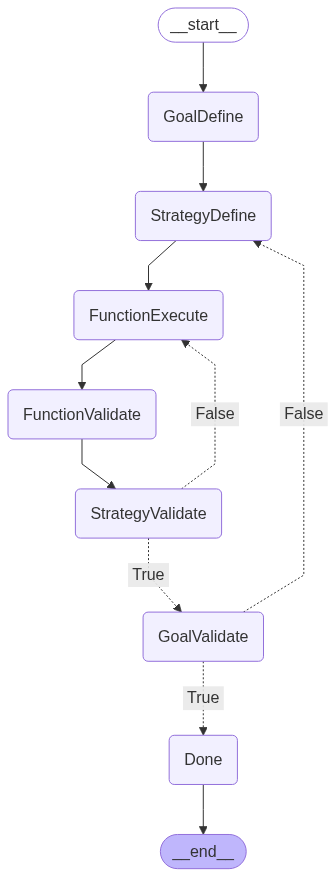

In [26]:
from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))


In [38]:
app_debug = workflow.compile(debug=True)

# 2) Prepare your initial state
init_state = {
    "query":        "What is the diameter of cable TFR4631025/040?",
    "sessionID":    6,
    "currentGoalID": None,
    "currentStrategyID": None,
    "currentFunctionID": None,
    "goalSatisfied": False
}

# 3) Run it—every node will print entry/exit and any prints inside your agents
final_state = app.invoke(
    init_state,
    config={"recursion_limit": 200}  # or some higher number
)


print("\n=== Final state ===")
print(final_state)

[Agenc_extract_product_nuntProd] Raw LLM output for product code(s): 'TFR4631025/040'
[func_extract_product_nu] Extracted product codes: ['TFR4631025/040']
[Execute] Extract Product Number: OK
[Execute] Table search: OK
[Execute] Filter table: OK
[Execute] Analyze data: OK
🎉 DONE – goal satisfied, no more work needed

=== Final state ===
{'query': 'What is the diameter of cable TFR4631025/040?', 'sessionID': 6, 'currentGoalID': 7, 'currentStrategyID': 8, 'currentFunctionID': 34, 'goalSatisfied': True, 'StrategySatisfied': True}


In [39]:
# 1) Compile with debug logging
app_debug = workflow.compile(debug=True)

# 2) Initial state
init_state = {
    "query":  "Which locator and cimptool should I contact for product RPT 235 4309/350",
    "sessionID": 7,
    "currentGoalID": None,
    "currentStrategyID": None,
    "currentFunctionID": None,
    "goalSatisfied": False
}

# 3) Run it
final_state = app_debug.invoke(           # ← use app_debug here
    init_state,
    config={"recursion_limit": 200}
)

print("\n=== Final state ===")
print(final_state)


[-1:checkpoint] State at the end of step -1:
{}
[0:tasks] Starting 1 task for step 0:
- __start__ -> {'currentFunctionID': None,
 'currentGoalID': None,
 'currentStrategyID': None,
 'goalSatisfied': False,
 'query': 'Which locator and cimptool should I contact for product RPT 235 '
          '4309/350',
 'sessionID': 7}
[0:writes] Finished step 0 with writes to 1 channel:
- __root__ -> {'currentFunctionID': None,
 'currentGoalID': None,
 'currentStrategyID': None,
 'goalSatisfied': False,
 'query': 'Which locator and cimptool should I contact for product RPT 235 '
          '4309/350',
 'sessionID': 7}
[0:checkpoint] State at the end of step 0:
{'__root__': {'currentFunctionID': None,
              'currentGoalID': None,
              'currentStrategyID': None,
              'goalSatisfied': False,
              'query': 'Which locator and cimptool should I contact for '
                       'product RPT 235 4309/350',
              'sessionID': 7}}
[1:tasks] Starting 1 task for step

GraphRecursionError: Recursion limit of 200 reached without hitting a stop condition. You can increase the limit by setting the `recursion_limit` config key.
For troubleshooting, visit: https://python.langchain.com/docs/troubleshooting/errors/GRAPH_RECURSION_LIMIT